In [1]:
import random
import heapq
from tqdm.notebook import tqdm as tqdm
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

  0%|          | 0/1 [00:00<?, ?it/s]

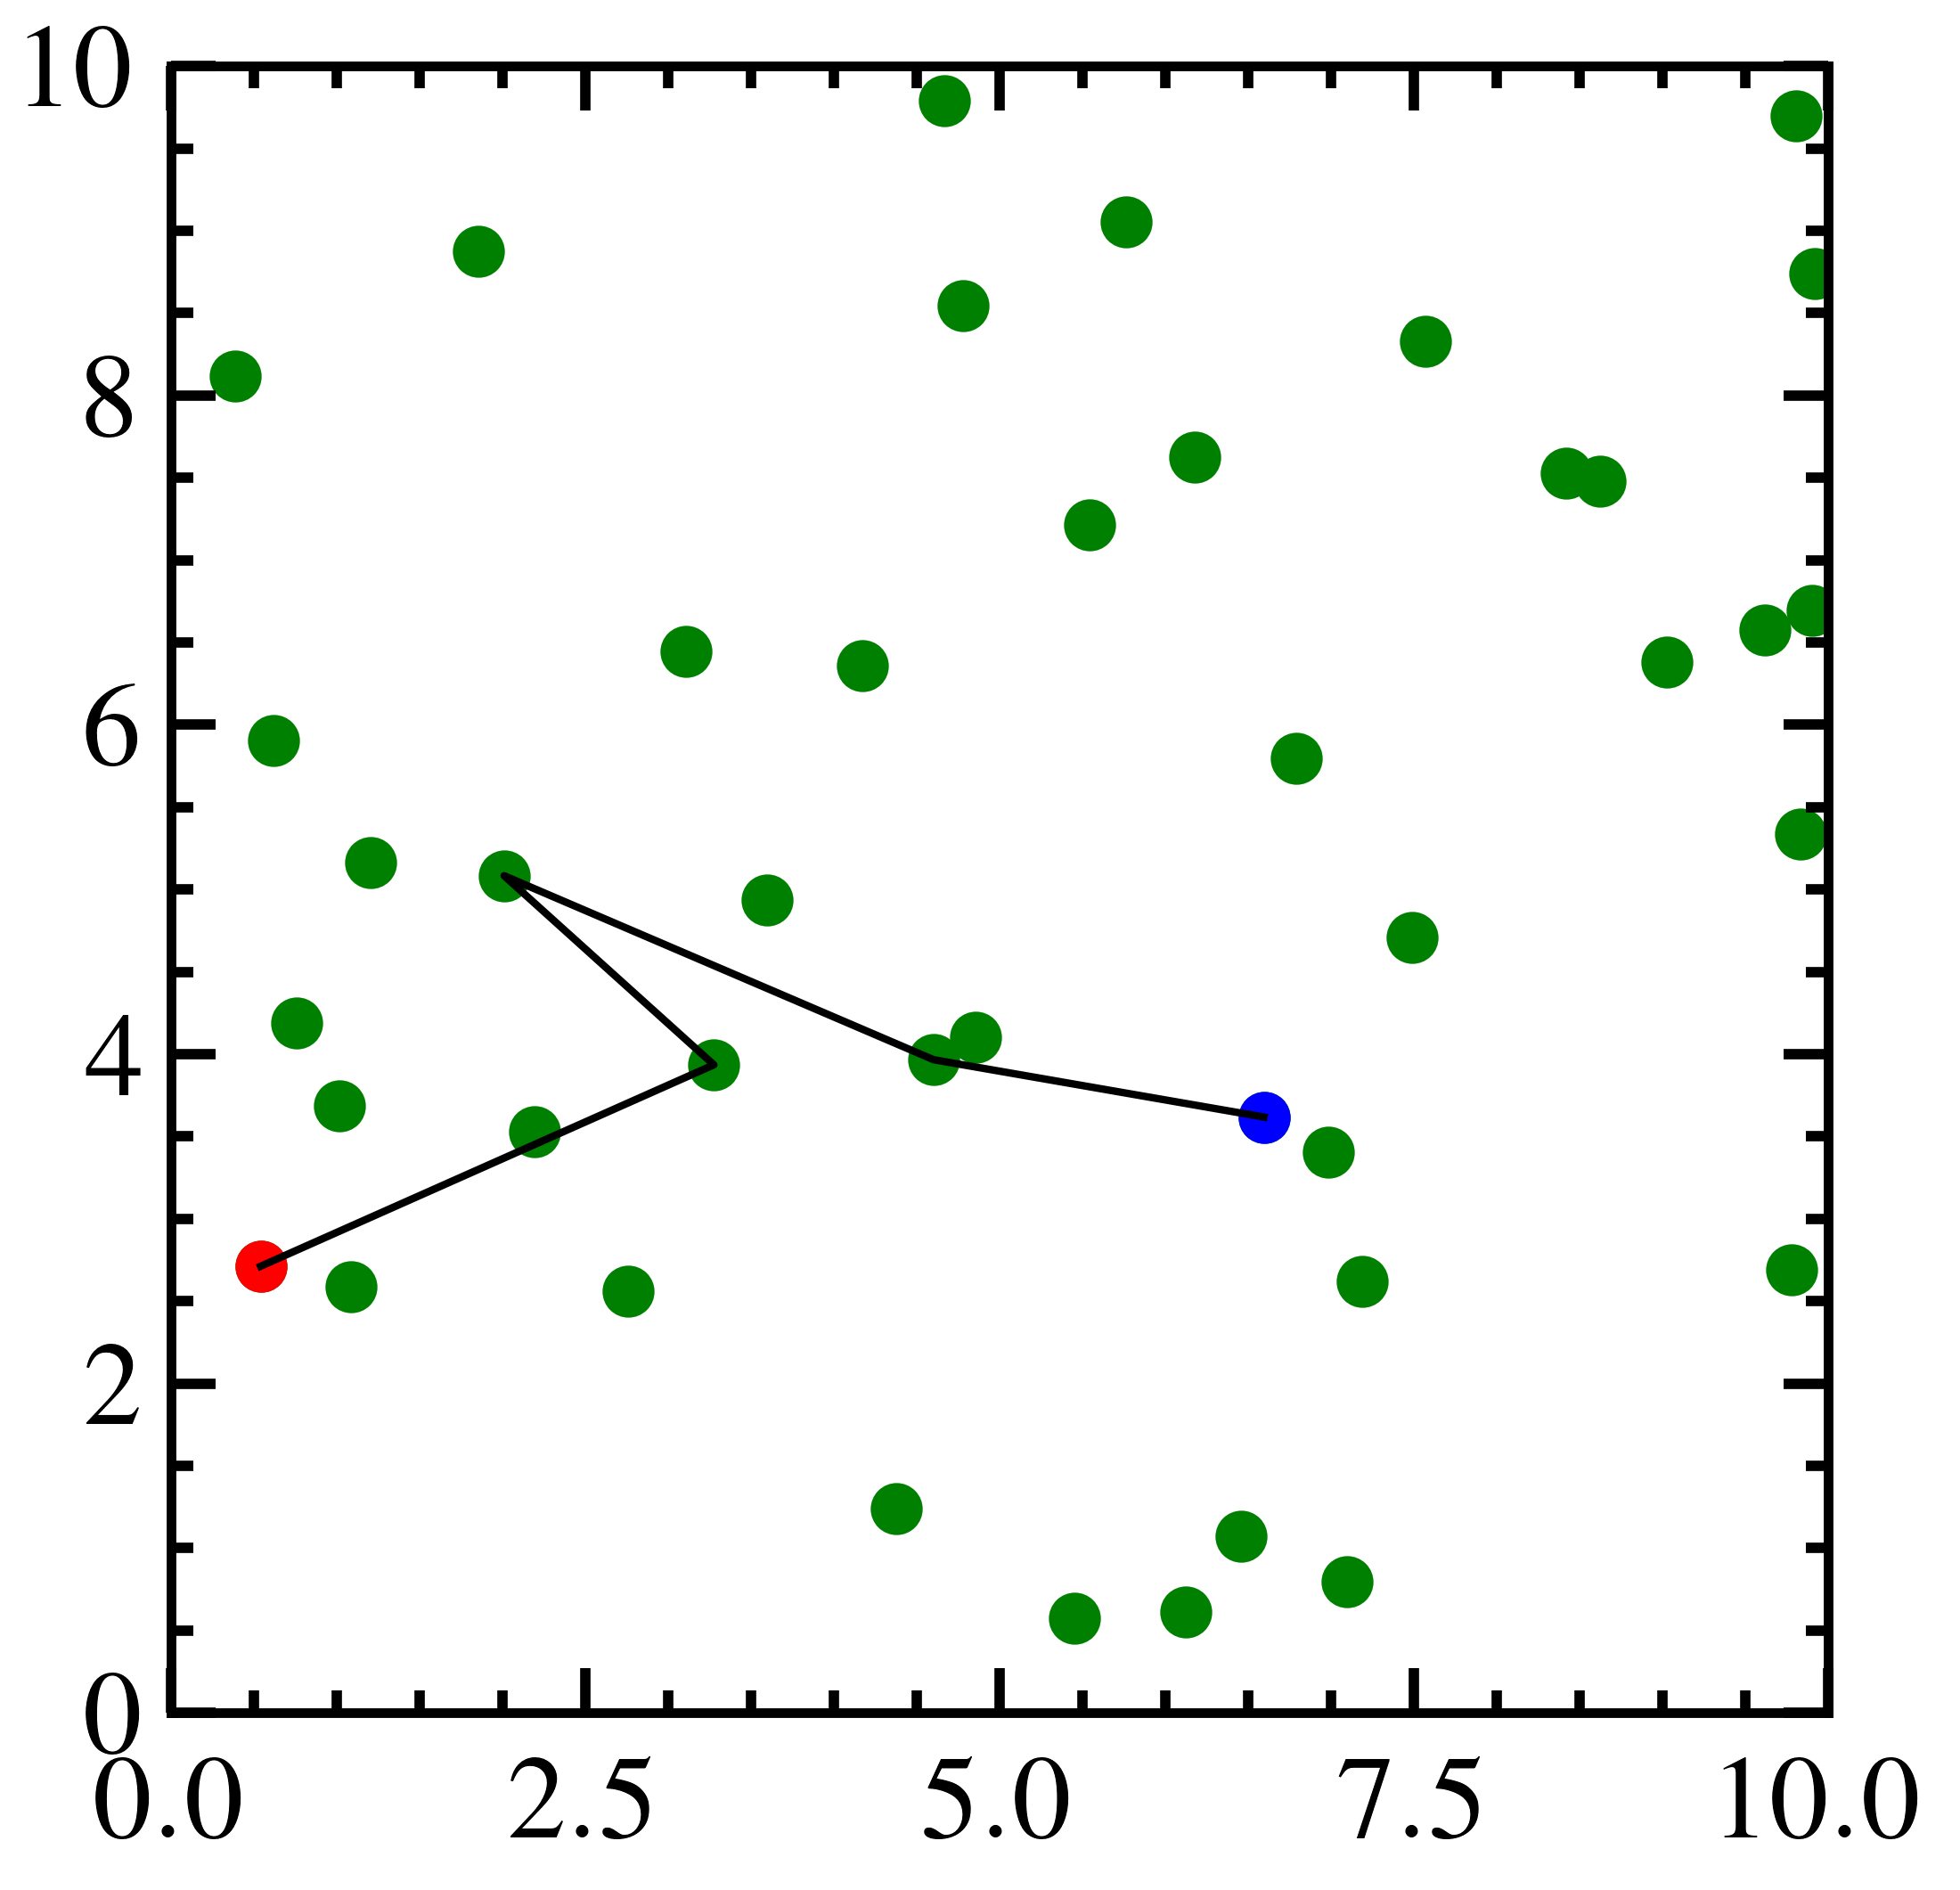

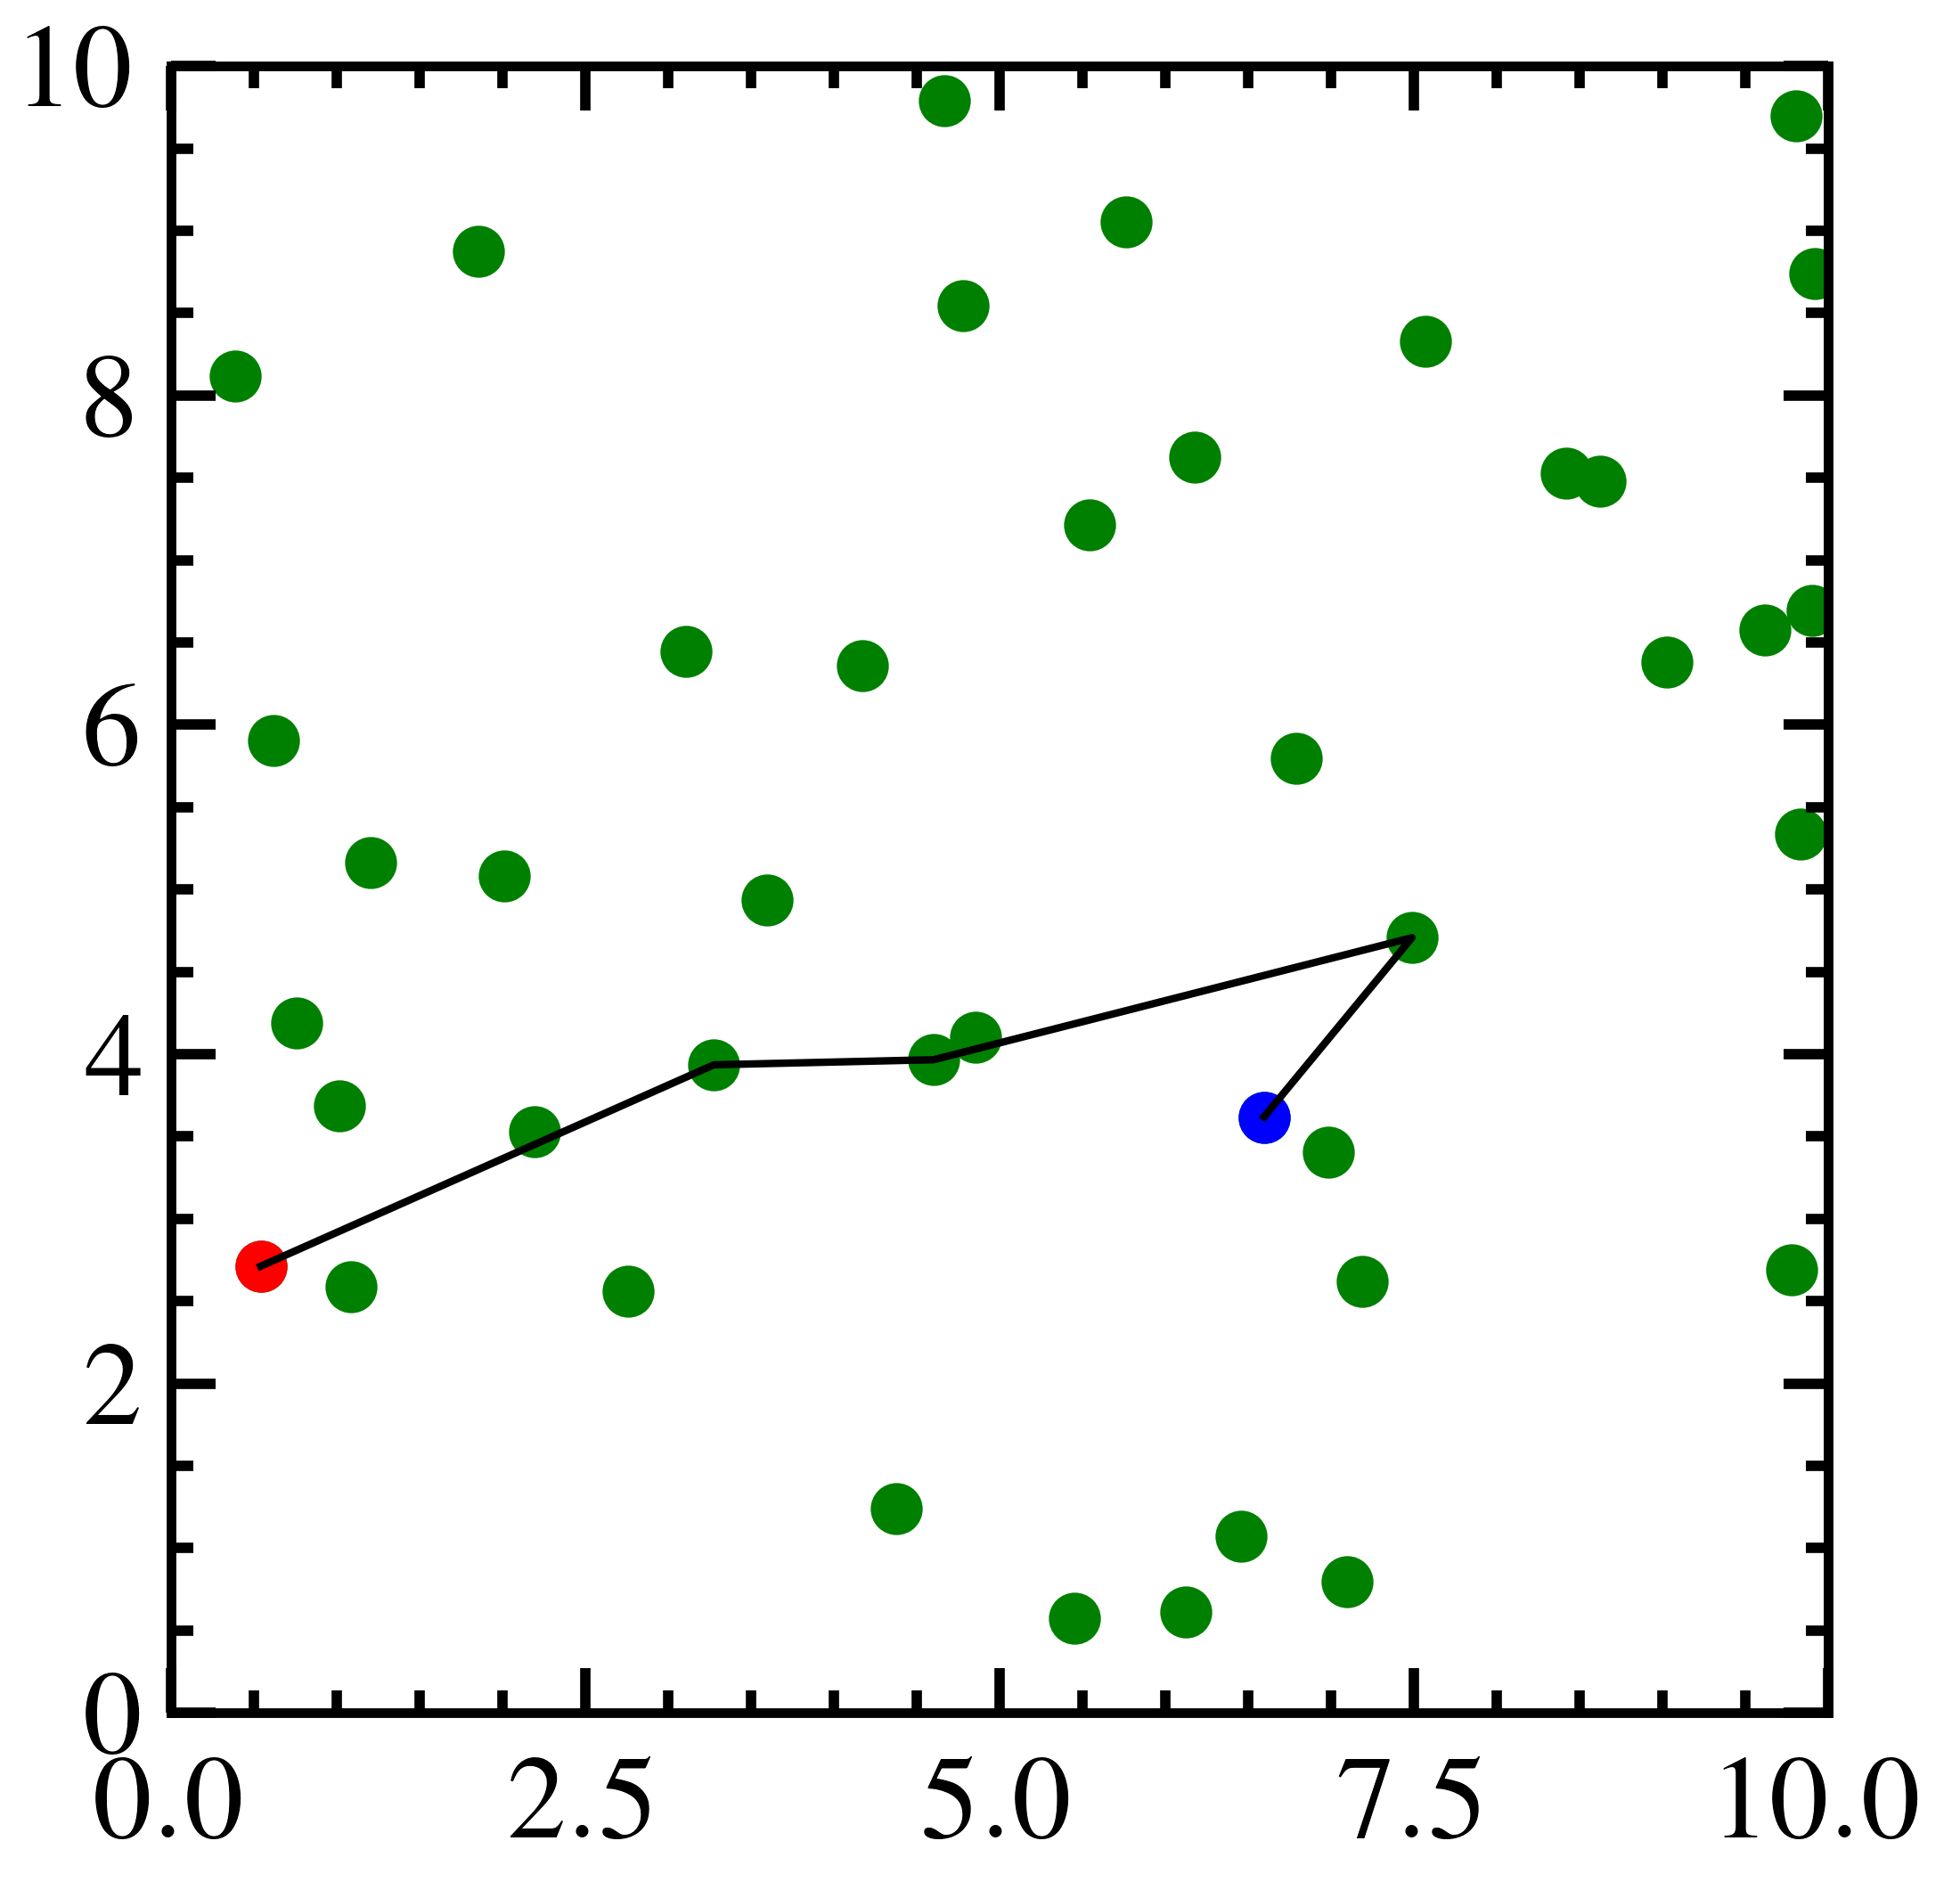

In [17]:
# environment parameter
W = 10
n_nodes = 10000
neighbors_thresh = 3

def draw_space(nodes, s_nid=None, r_nid=None, path=None):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, W)
    ax.set_ylim(0, W)
    valid_nodes = list(filter(lambda n: n['valid'], nodes))
    ax.scatter([node['coord'][0] for node in valid_nodes], [node['coord'][1] for node in valid_nodes], c='green')
    if path != None:
        s_nid = path[0]
        r_nid = path[-1]
        ax.plot([nodes[nid]['coord'][0] for nid in path], [nodes[nid]['coord'][1] for nid in path], c='black')
    if s_nid != None:
        ax.scatter([nodes[s_nid]['coord'][0]], [nodes[s_nid]['coord'][1]], c='red')
    if r_nid != None:
        ax.scatter([nodes[r_nid]['coord'][0]], [nodes[r_nid]['coord'][1]], c='blue')
    plt.show()
    return 0

def choose_sr(nodes):
    valid_nids = list(filter(lambda nid: nodes[nid]['valid'], range(len(nodes))))
    if len(valid_nids) < 2:
        return (None, None)
    else:
        return random.sample(valid_nids, 2)    

def find_neighbors(nodes, nid, d_thresh):
    neighbors = []
    for i in range(len(nodes)):
        if nodes[i]['valid'] and \
            (nodes[i]['coord'][0] - nodes[nid]['coord'][0])**2 + (nodes[i]['coord'][1] - nodes[nid]['coord'][1])**2 <= d_thresh**2:
            neighbors.append(i)
    return neighbors


# experiment parameters
n_experiments = 100

max_pathlen = 5
max_paths = 4    # N
max_degree = 5

setTree_delay = 1
pathDiscover_delay = 1

lambda_join = 76800
lambda_drop = 300

t_path_init = 1000
t_end = 3000

stat_interval = 1
    
# node logic
def setTree_node(t, q_events, nodes, paths, nid, path, r_nid):
    if not nodes[nid]['valid']:
        return
        
    if nid == r_nid:
        if len(nodes[nid]['paths']) < max_paths:        
            # print('t: %f (path setTree reached) path=%s, r=%d' % (t, str(path), r_nid))
            pid = len(paths)
            paths.append({'path': path, 't_init': None, 't_fin': None})
            nodes[nid]['paths'].append(pid)
            
            heapq.heappush(q_events, (t, 'path', 'pathDiscover', pid, len(path) - 1))
            return
        
    elif len(path) == max_pathlen or nid in path[:-1]:
        return
    else:
        neighbors = find_neighbors(nodes, nid, neighbors_thresh)
        for neighbor in random.sample(neighbors, min(max_degree, len(neighbors))):
            heapq.heappush(q_events, (t + setTree_delay, 'path', 'setTree', path + [neighbor], r_nid))    
        return

def pathDiscover_node(t, q_events, nodes, paths, nid, pid, pos):
    if not nodes[nid]['valid']:
        return        
    path = paths[pid]['path']
    nodes[nid]['paths'].append(pid)
    
    if pos == 0:
        # print('t: %f (path pathDiscover reached) path=%s' % (t, str(path)))    
        paths[pid]['t_init'] = t

        if n_experiments == 1:
            # print path
            draw_space(nodes, path=path)
        return
    else:
        if nodes[path[pos - 1]]['valid']:
            heapq.heappush(q_events, (t + pathDiscover_delay, 'path', 'pathDiscover', pid, pos - 1))
        return

def join_node(t, q_events, nodes, paths, nid):
    nodes[nid]['coord'] = (np.random.uniform(0, W), np.random.uniform(0, W))
    return
    
def drop_node(t, q_events, nodes, paths, nid):
    for pid in nodes[nid]['paths']:
        if paths[pid]['t_fin'] == None:
            paths[pid]['t_fin'] = t
    nodes[nid]['paths'] = []

def stat_exp(t, q_events, nodes, paths, ctrs, stats):
    valid_nids = list(filter(lambda nid: nodes[nid]['valid'], range(len(nodes))))
    stats.append((t, len(valid_nids)))
    heapq.heappush(q_events, (t + stat_interval, 'stat'))    


results = []
for i_exps in tqdm(range(n_experiments)):
    # initialize nodes
    nodes = []
    p_off = (1/lambda_drop) / ((1/lambda_join) + (1/lambda_drop))
    for i in range(n_nodes):
        if random.random() <= p_off:
            nodes.append({'valid': False, 'paths': []})
        else:
            nodes.append({'valid': True, 'coord': (np.random.uniform(0, W), np.random.uniform(0, W)), 'paths': []})

    # initialize counters
    ctrs = {}
    
    # initialize event queue
    t = 0
    q_events = []
    heapq.heapify(q_events)
    for nid in range(n_nodes):
        lambda_ = lambda_drop if nodes[nid]['valid'] else lambda_join
        heapq.heappush(q_events, (np.random.exponential(lambda_), 'node', nid))
    
    # add a path setup event
    paths = []
    heapq.heappush(q_events, (t_path_init, 'path', 'init'))
    s_nid, r_nid = None, None

    # add a statistics event
    stats = []
    heapq.heappush(q_events, (t, 'stat'))
    
    # start simulation
    while t < t_end:
        event = heapq.heappop(q_events)
        t, op = event[0], event[1]
        if op == 'node':
            nid = event[2]
            nodes[nid]['valid'] = not nodes[nid]['valid']
            # print('t=%f: node %d %s' % (t, nid, 'joins' if nodes[nid]['valid'] else 'drops'))
            if nodes[nid]['valid']:
                # node join
                join_node(t, q_events, nodes, paths, nid)
                if not 'node/join' in ctrs:
                    ctrs['node/join'] = 0
                ctrs['node/join'] += 1
            else:
                # node drop
                drop_node(t, q_events, nodes, paths, nid)
                if not 'node/drop' in ctrs:
                    ctrs['node/drop'] = 0
                ctrs['node/drop'] += 1
                
            lambda_ = lambda_drop if nodes[nid]['valid'] else lambda_join
            heapq.heappush(q_events, (t + np.random.exponential(lambda_), 'node', nid))
    
        elif op == 'path':
            cmd = event[2]
            if cmd == 'init':
                s_nid, r_nid = choose_sr(nodes)
                if s_nid == None:
                    raise RuntimeError('No sender-receiver pair!')
                    continue
                # print('t: %f (path init) s=%d, r=%d' % (t, s_nid, r_nid))
                heapq.heappush(q_events, (t, 'path', 'setTree', [s_nid], r_nid, max_pathlen))
                # draw_space(nodes, s_nid=s_nid, r_nid=r_nid)
                
            elif cmd == 'setTree':
                path, r_nid = event[3], event[4]
                # print('t: %f (path setTree) path=%s, r=%d' % (t, str(path), r_nid))
                setTree_node(t, q_events, nodes, paths, path[-1], path, r_nid)
                if not 'path/setTree' in ctrs:
                    ctrs['path/setTree'] = 0
                ctrs['path/setTree'] += 1
                
            elif cmd == 'pathDiscover':
                pid, pos = event[3], event[4]
                # print('t: %f (path pathDiscover) path=%s, pos=%d' % (t, str(paths[pid]['path']), pos))
                pathDiscover_node(t, q_events, nodes, paths, paths[pid]['path'][pos], pid, pos)
                if not 'path/pathDiscover' in ctrs:
                    ctrs['path/pathDiscover'] = 0
                ctrs['path/pathDiscover'] += 1
                    
        elif op == 'stat':
            stat_exp(t, q_events, nodes, paths, ctrs, stats)
            
    results.append({'paths': paths, 'ctrs': ctrs, 'stats': stats})


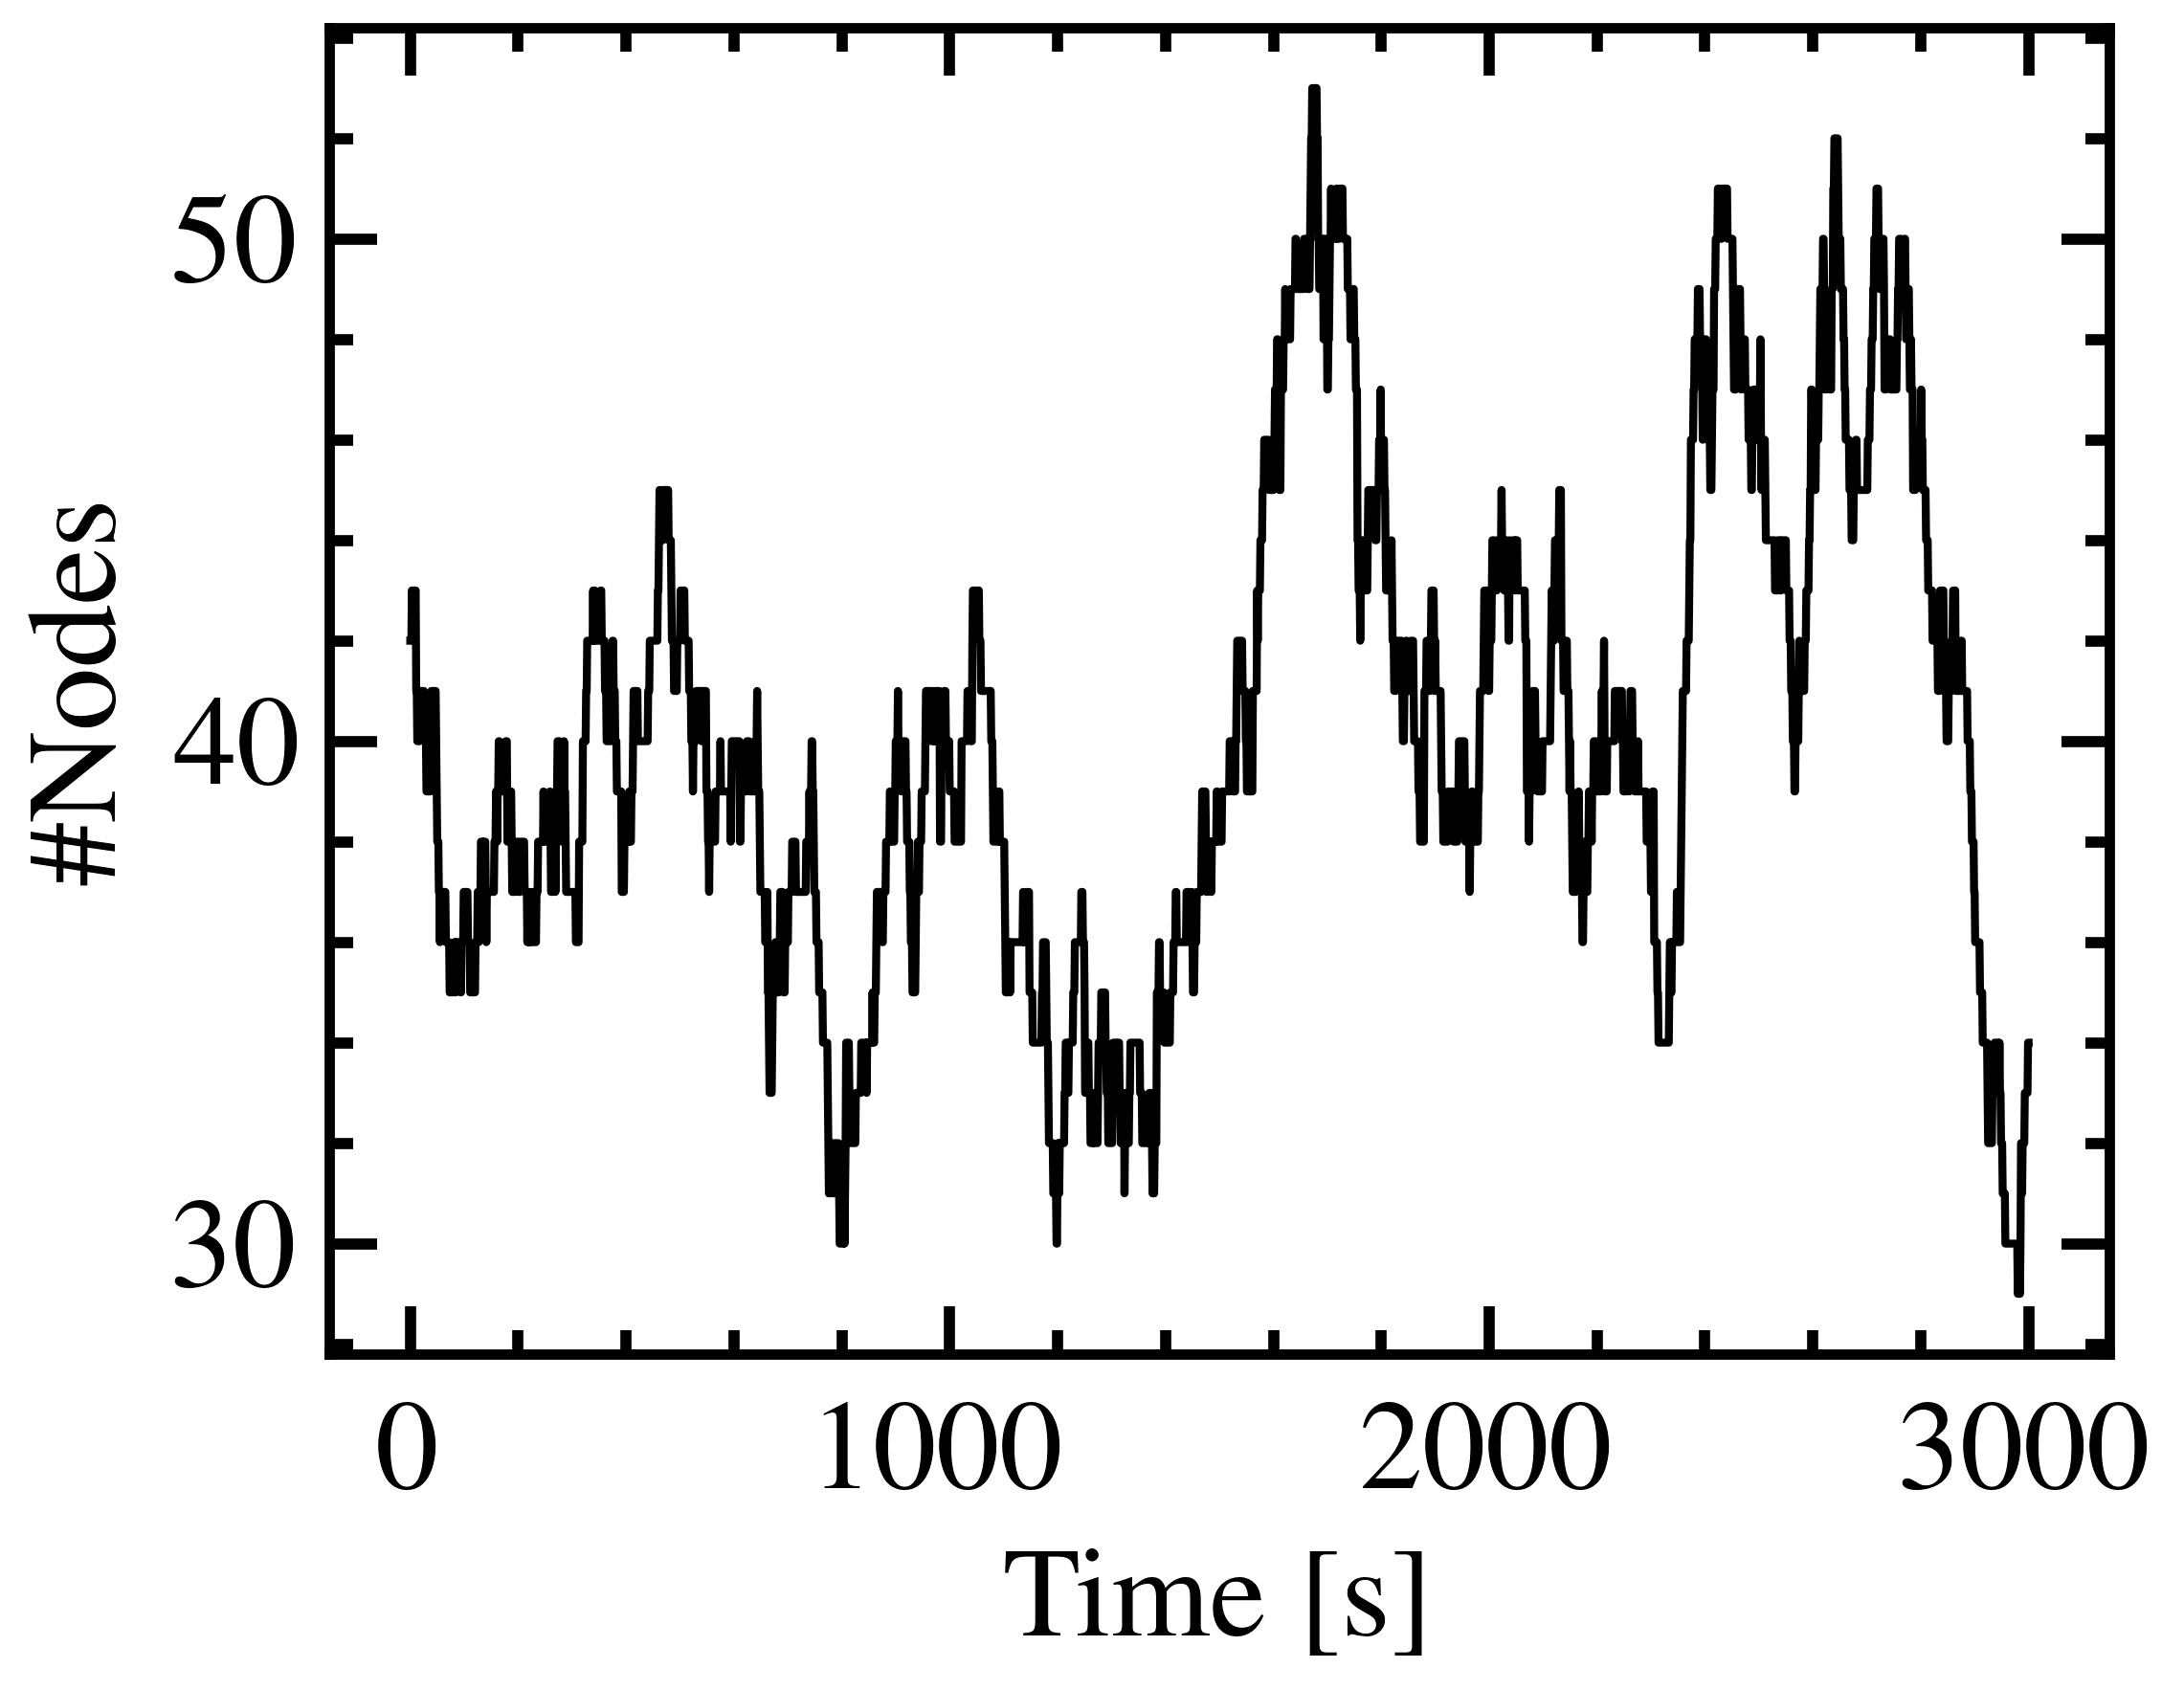

In [9]:
fig, ax = plt.subplots(figsize=(4, 3))
log = results[0]['stats']
x = [l[0] for l in log]
y = [l[1] for l in log]
ax.set_xlabel('Time [s]')
ax.set_ylabel('\\#Nodes')
plt.plot(x, y)
plt.show()

In [10]:
def cdf(l):
    x = [min(l)] + sorted(l)
    y = np.arange(0, len(l) + 1) / len(l)
    return x, y

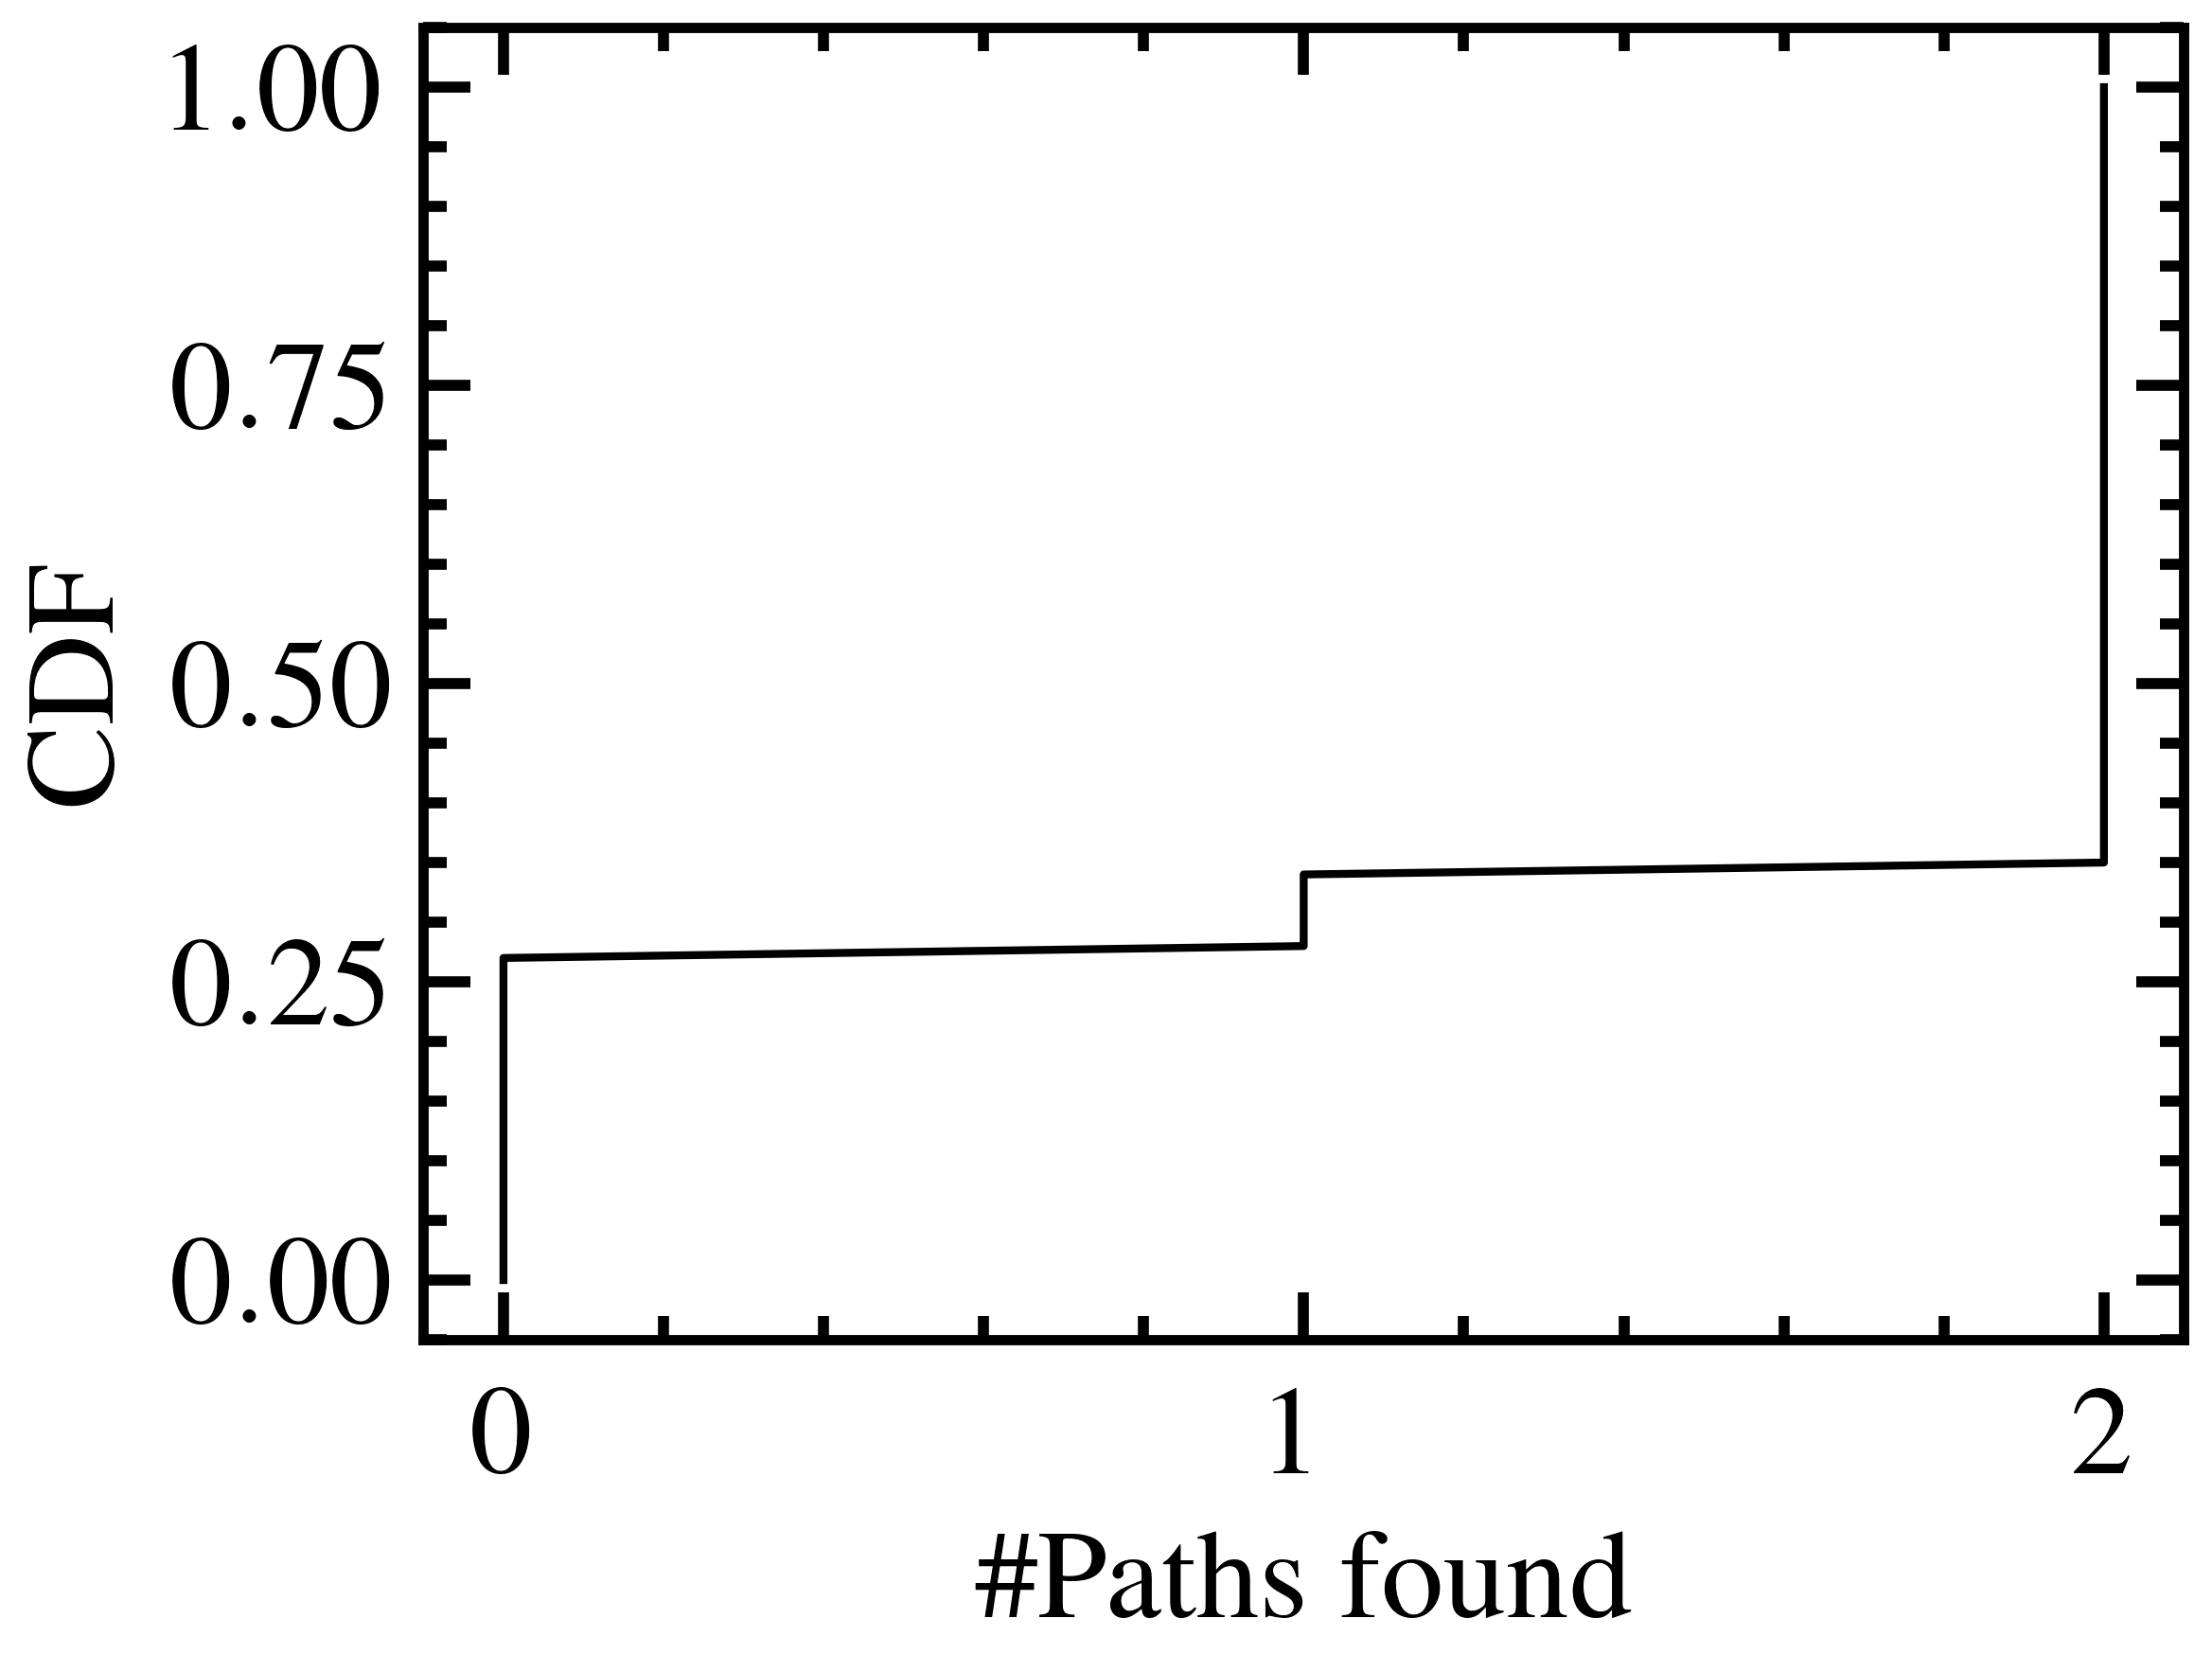

In [11]:
plt.style.use(['science','ieee'])
plt.rcParams["font.size"] = 16
plt.rcParams['font.weight'] = 400
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 1.3

plt.rcParams['xtick.major.pad'] = 6
plt.rcParams['xtick.major.width'] = 1.4
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.width'] = 1.4
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.width'] = 1.4
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.width'] = 1.4
plt.rcParams['ytick.minor.size'] = 3

fig, ax = plt.subplots(figsize=(4, 3))
n_path_established = [len(r['paths']) for r in results]
x, y = cdf(n_path_established)
ax.set_xlabel('\\#Paths found')
ax.set_ylabel('CDF')
plt.plot(x, y)
plt.show()

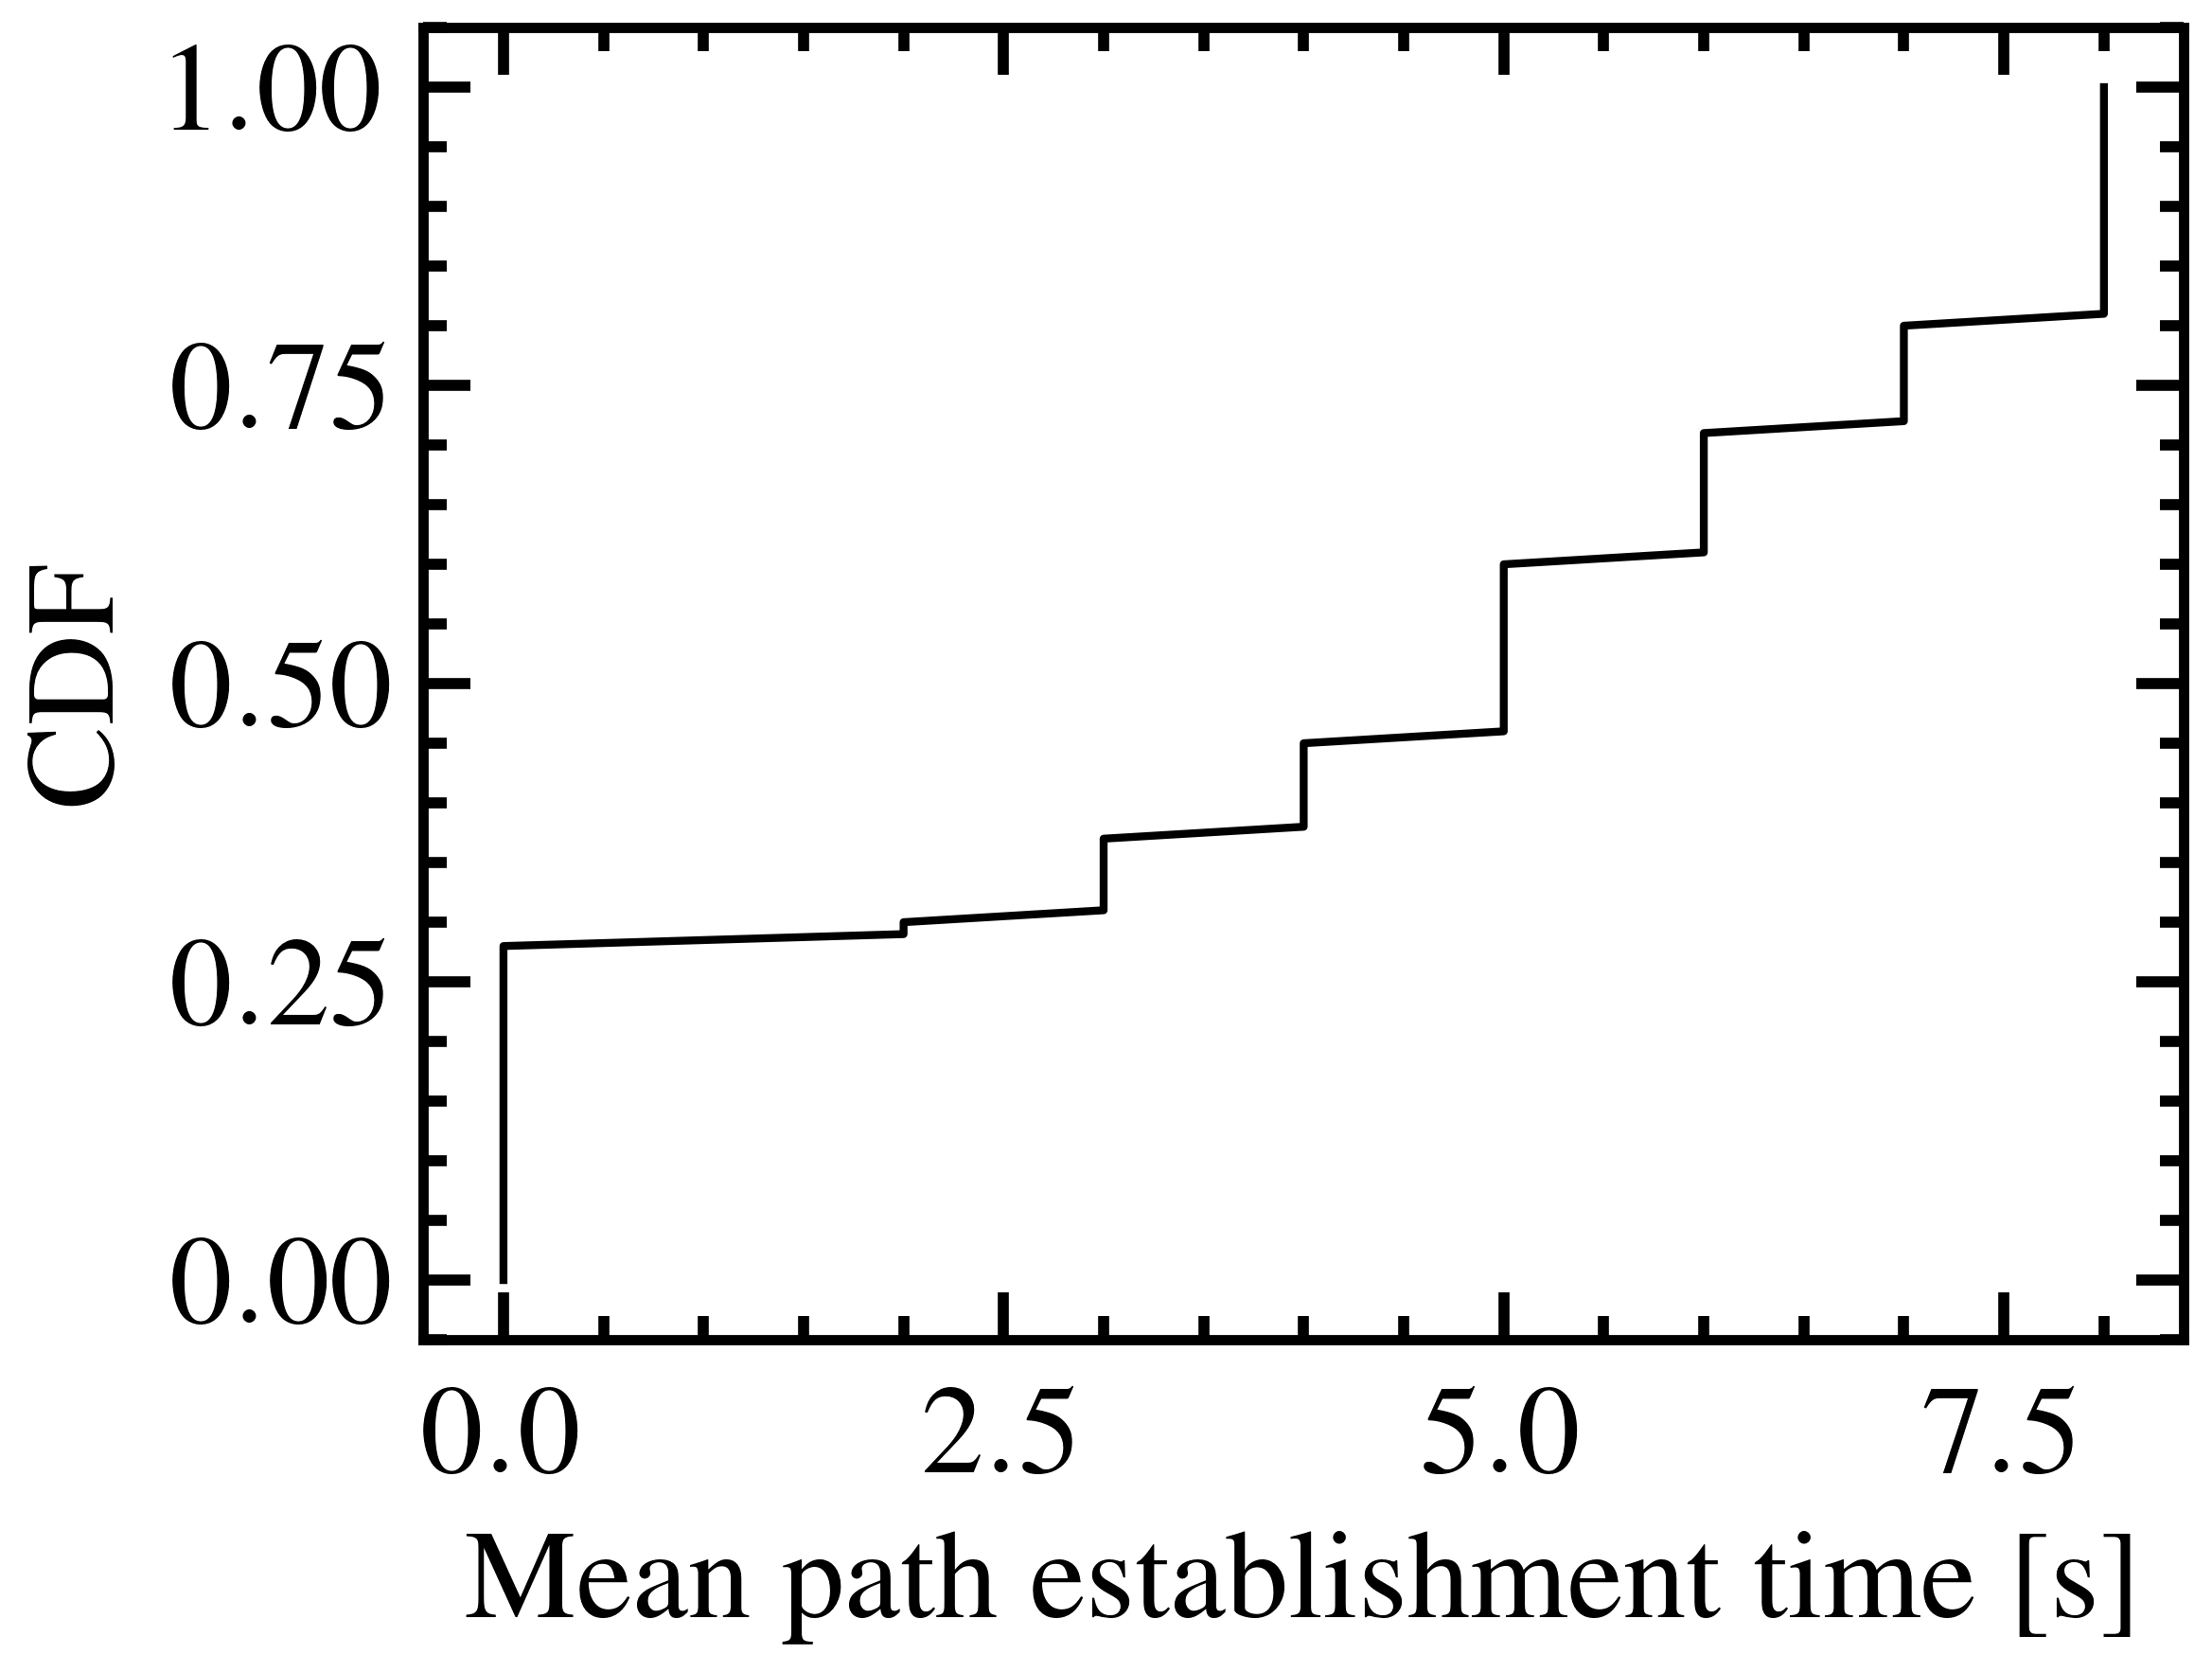

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
mean_path_lifespan = []
for r in results:
    if len(r['paths']) == 0:
        mean_path_lifespan.append(0)
    else:
        mean_path_lifespan.append(np.mean([0 if path['t_init'] == None else path['t_init'] -  t_path_init for path in r['paths']]))
x, y = cdf(mean_path_lifespan)
ax.set_xlabel('Mean path establishment time [s]')
ax.set_ylabel('CDF')
plt.plot(x, y)
plt.show()

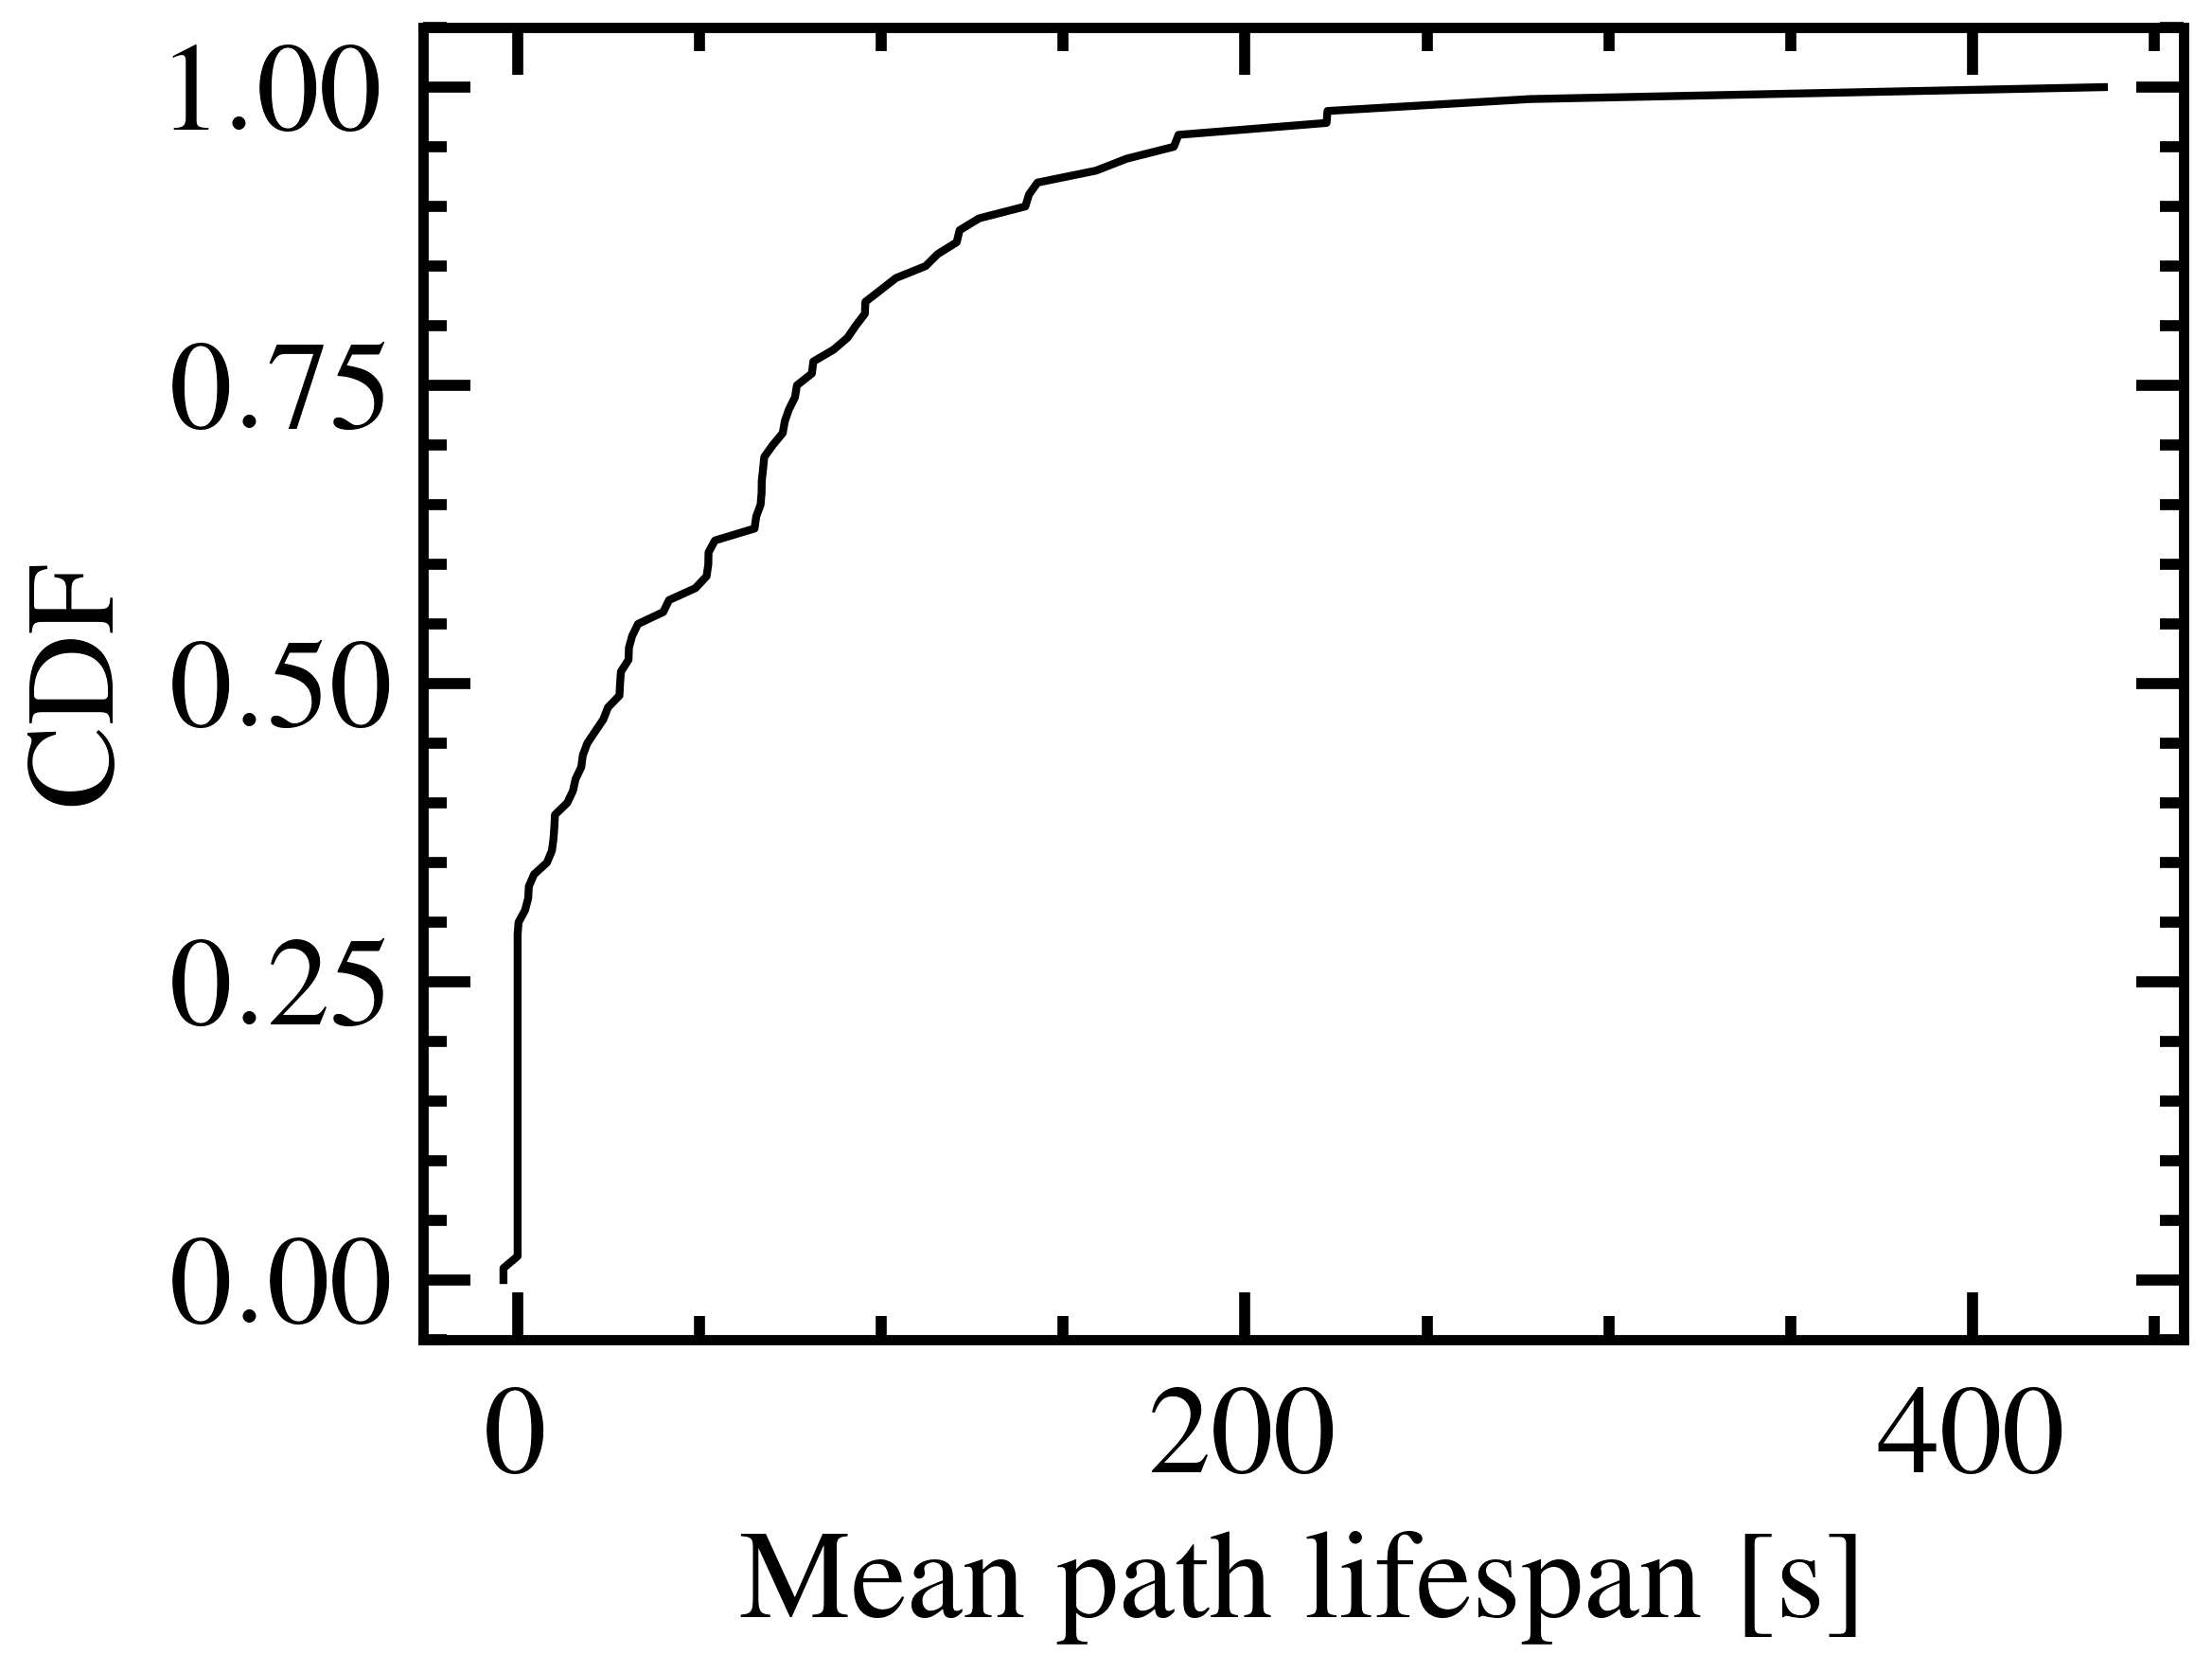

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))
mean_path_lifespan = []
for r in results:
    if len(r['paths']) == 0:
        mean_path_lifespan.append(0)
    else:
        mean_path_lifespan.append(np.mean([0 if path['t_init'] == None else path['t_fin'] - path['t_init'] for path in r['paths']]))
x, y = cdf(mean_path_lifespan)
ax.set_xlabel('Mean path lifespan [s]')
ax.set_ylabel('CDF')
plt.plot(x, y)
plt.show()

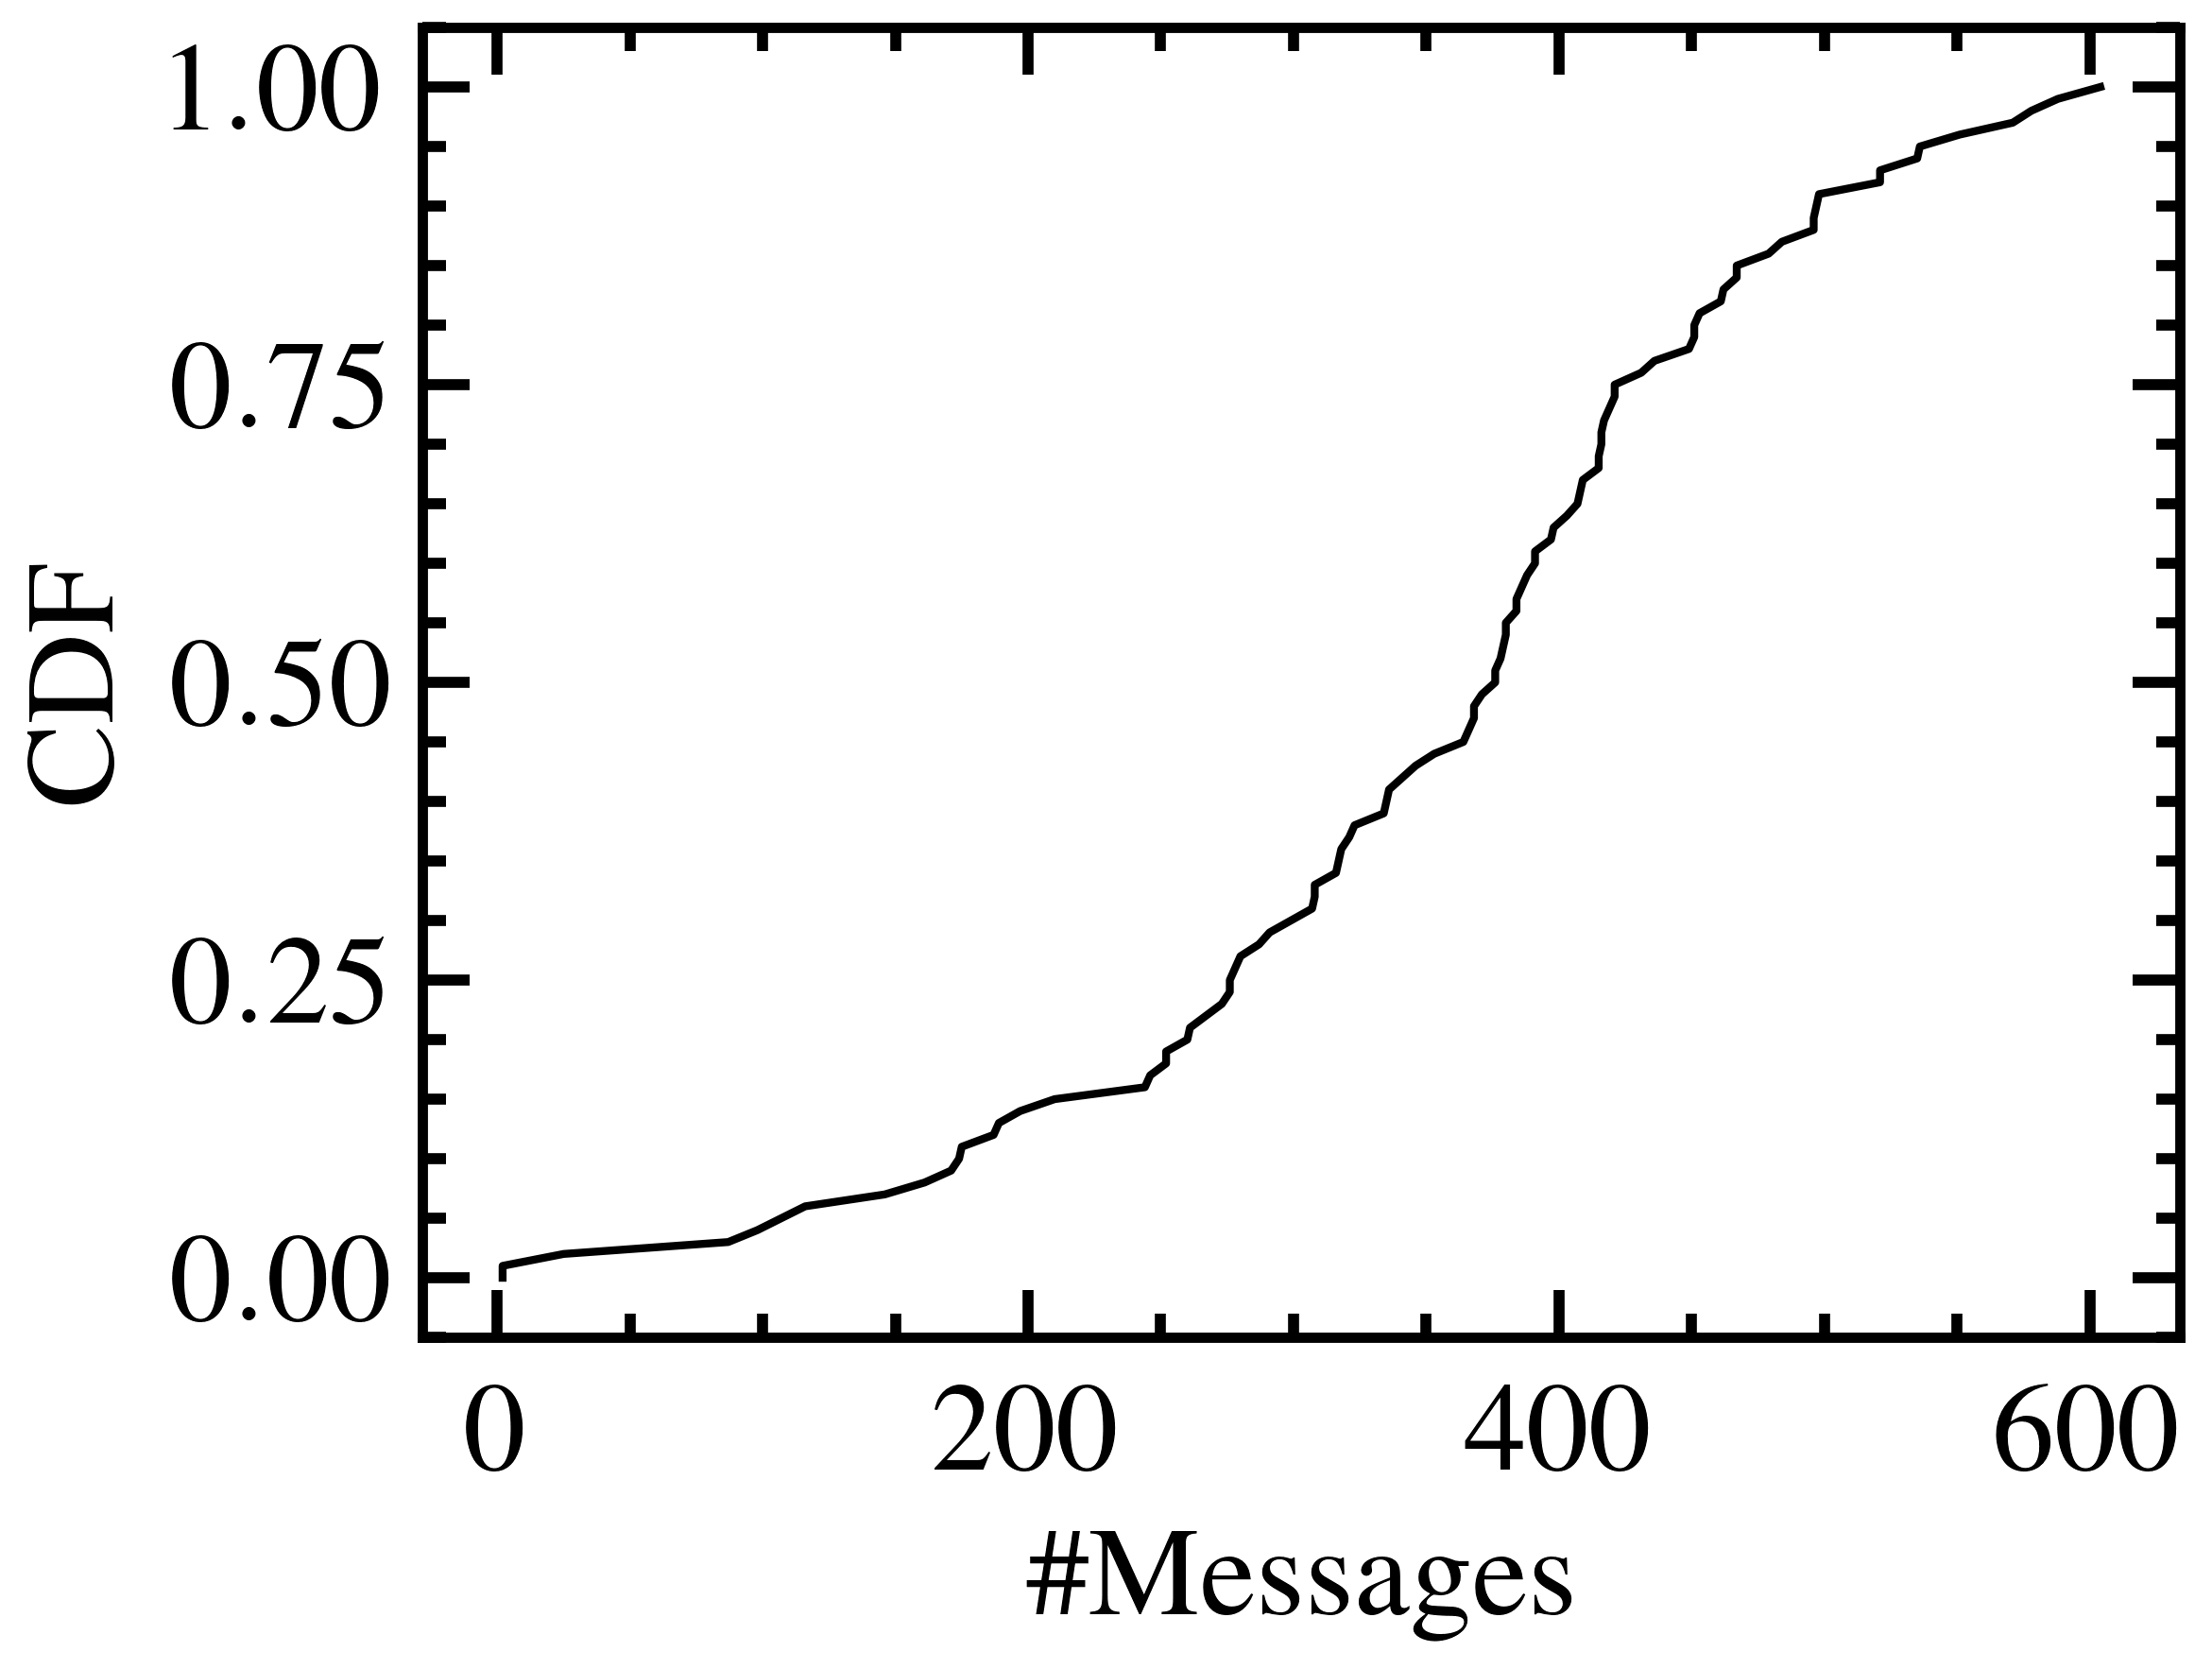

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))
n_msgs = [r['ctrs']['path/setTree'] + (r['ctrs']['path/pathDiscover'] if 'path/pathDiscover' in r['ctrs'] else 0) for r in results]
x, y = cdf(n_msgs)
ax.set_xlabel('\\#Messages')
ax.set_ylabel('CDF')
plt.plot(x, y)
plt.show()